In [26]:
import os
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
import matplotlib.pyplot as plt

# Configuration
CHECKPOINT_DIR = "/content/drive/MyDrive/Colab Notebooks/checkpoints"
BATCH_SIZE = 64
EPOCHS = 150
LR = 2e-3
IMG_SIZE = 48
EMOTIONS = ['Angry', 'Disgust', 'Fear', 'Happy', 'Sad', 'Surprise', 'Neutral']

# Create checkpoint directory
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

# Custom Dataset
class FER2013Dataset(Dataset):
    def __init__(self, df, transform=None, img_size=48):
        self.df = df
        self.transform = transform
        self.img_size = img_size
        # Filter rows with correct pixel count
        self.df = self.df[self.df['pixels'].apply(lambda x: len(x.split()) == img_size * img_size)]

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        pixels = self.df.iloc[idx]['pixels']
        try:
            image = np.fromstring(pixels, dtype='uint8', sep=' ').reshape(self.img_size, self.img_size)
        except ValueError as e:
            print(f"Skipping invalid row {idx}: {e}")
            return self.__getitem__((idx + 1) % len(self))
        image = image.astype(np.float32) / 255.0
        label = self.df.iloc[idx]['emotion']

        if self.transform:
            image = self.transform(image)
        else:
            image = torch.tensor(image).unsqueeze(0)

        return image, label

In [27]:
# Model
class EmotionCNN(nn.Module):
    def __init__(self):
        super(EmotionCNN, self).__init__()
        self.cnn = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Dropout(0.5)
        )
        self.classifier = nn.Sequential(
            nn.Linear(128 * 6 * 6, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, 7)
        )

    def forward(self, x):
        x = self.cnn(x)
        x = x.view(x.size(0), -1)
        return self.classifier(x)

class FocalLoss(nn.Module):
    def __init__(self, gamma=4.0, alpha=None, reduction='mean'):
        super(FocalLoss, self).__init__()
        self.gamma = gamma
        self.alpha = alpha if alpha is not None else torch.ones(7).to(device)
        self.reduction = reduction

    def forward(self, inputs, targets):
        ce_loss = nn.functional.cross_entropy(inputs, targets, reduction='none')
        pt = torch.exp(-ce_loss)
        focal_loss = self.alpha[targets] * (1 - pt) ** self.gamma * ce_loss
        if self.reduction == 'mean':
            return focal_loss.mean()
        return focal_loss.sum()

# Initialize model and device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = EmotionCNN().to(device)


In [28]:
from torch.utils.data import WeightedRandomSampler

def prepare_loaders(df_path='/content/drive/MyDrive/Colab Notebooks/fer2013_2.csv'):
    df = pd.read_csv(df_path)
    df = df[df['pixels'].apply(lambda x: len(x.split()) == IMG_SIZE * IMG_SIZE)]

    train_transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomRotation(10),
        transforms.RandomAffine(degrees=0, translate=(0.15, 0.15), scale=(0.8, 1.2)),
        transforms.RandomApply([transforms.GaussianBlur(kernel_size=3)], p=0.4),
        transforms.RandomApply([transforms.ColorJitter(brightness=0.2, contrast=0.2)], p=0.3),
        transforms.Normalize((0.5,), (0.5,))
    ])
    test_transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.5,), (0.5,))
    ])

    train_df, test_df = train_test_split(df, test_size=0.2, stratify=df['emotion'], random_state=42)

    # Weighted sampler for training
    class_counts = train_df['emotion'].value_counts().sort_index()
    class_weights = 1.0 / class_counts
    sample_weights = [class_weights[emotion] for emotion in train_df['emotion']]
    sampler = WeightedRandomSampler(sample_weights, len(sample_weights), replacement=True)

    train_dataset = FER2013Dataset(train_df, train_transform, IMG_SIZE)
    test_dataset = FER2013Dataset(test_df, test_transform, IMG_SIZE)
    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, sampler=sampler)
    test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

    return train_loader, test_loader

In [31]:

from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Resuming training from epoch 115
Epoch [116/150] | Train Loss: 0.9207, Train Acc: 20.17% | Test Loss: 0.8377, Test Acc: 31.27% | LR: 7.81e-06
Epoch [117/150] | Train Loss: 0.9275, Train Acc: 18.79% | Test Loss: 0.8375, Test Acc: 32.00% | LR: 3.91e-06
Epoch [118/150] | Train Loss: 0.9383, Train Acc: 19.70% | Test Loss: 0.8378, Test Acc: 32.00% | LR: 3.91e-06
Epoch [119/150] | Train Loss: 0.9122, Train Acc: 20.22% | Test Loss: 0.8388, Test Acc: 31.82% | LR: 3.91e-06
Epoch [120/150] | Train Loss: 0.9229, Train Acc: 19.72% | Test Loss: 0.8372, Test Acc: 31.64% | LR: 3.91e-06
Epoch [121/150] | Train Loss: 0.9319, Train Acc: 18.97% | Test Loss: 0.8374, Test Acc: 31.73% | LR: 3.91e-06
Epoch [122/150] | Train Loss: 0.9277, Train Acc: 18.63% | Test Loss: 0.8386, Test Acc: 31.64% | LR: 3.91e-06
Epoch [123/150] | Train Loss: 0.9310, Train Acc: 19.26% | Test Loss: 0.8388, Test Acc: 31.91% | LR: 1.95e-06
Epoch [124/150] | Train Loss: 0.9355, Train Acc: 18.94% | Test Loss: 0.8375, Test Acc: 31.64% |

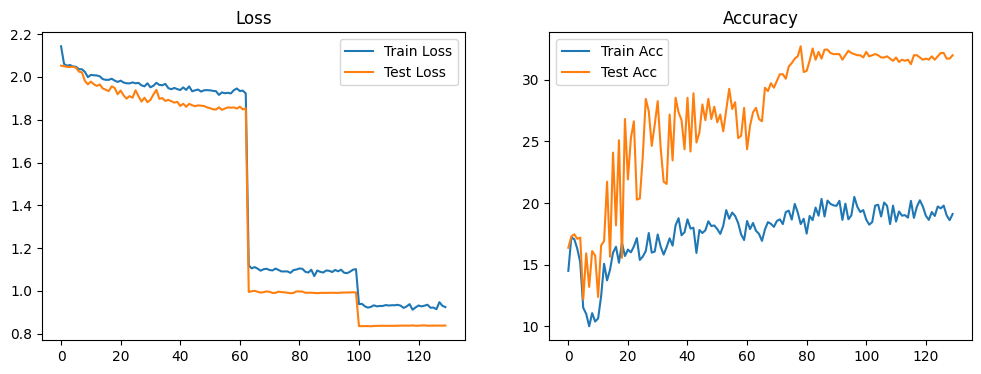

In [29]:
# Training Function
def train_model(model, train_loader, test_loader, optimizer, device):
    train_losses, test_losses, train_accs, test_accs = [], [], [], []
    early_stopping_patience = 10
    best_val_loss = float('inf')
    patience_counter = 0
    start_epoch = 0
    accumulation_steps = 8

    # Class weights for focal loss
    all_labels = []
    for _, labels in train_loader:
        all_labels.append(labels.cpu())
    all_labels = torch.cat(all_labels).numpy()
    class_weights = compute_class_weight('balanced', classes=np.unique(all_labels), y=all_labels)
    class_weights = torch.tensor(class_weights, dtype=torch.float32).to(device)

    criterion = FocalLoss(gamma=4.0, alpha=class_weights)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=2)

    # Load checkpoint if compatible
    checkpoint_path = os.path.join(CHECKPOINT_DIR, 'last_checkpoint.pth')
    if os.path.exists(checkpoint_path):
        try:
            checkpoint = torch.load(checkpoint_path, map_location=device)
            model.load_state_dict(checkpoint['model_state'])
            optimizer.load_state_dict(checkpoint['optimizer_state'])
            scheduler.load_state_dict(checkpoint['scheduler_state'])
            start_epoch = checkpoint['epoch'] + 1
            train_losses = checkpoint['train_losses']
            test_losses = checkpoint['test_losses']
            train_accs = checkpoint['train_accs']
            test_accs = checkpoint['test_accs']
            print(f"Resuming training from epoch {start_epoch}")
        except RuntimeError as e:
            print(f"Checkpoint loading failed due to state_dict mismatch: {e}")
            print("Starting training from epoch 0")
            train_losses, test_losses, train_accs, test_accs = [], [], [], []

    for epoch in range(start_epoch, EPOCHS):
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0
        optimizer.zero_grad()

        for i, (images, labels) in enumerate(train_loader):
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss = loss / accumulation_steps
            loss.backward()
            if (i + 1) % accumulation_steps == 0:
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()
                optimizer.zero_grad()
            running_loss += loss.item() * accumulation_steps
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        train_loss = running_loss / len(train_loader)
        train_acc = 100 * correct / total
        train_losses.append(train_loss)
        train_accs.append(train_acc)

        # Validation
        model.eval()
        test_loss = 0.0
        correct = 0
        total = 0
        with torch.no_grad():
            for images, labels in test_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                test_loss += loss.item()
                _, predicted = torch.max(outputs.data, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()

        test_loss = test_loss / len(test_loader)
        test_acc = 100 * correct / total
        test_losses.append(test_loss)
        test_accs.append(test_acc)

        scheduler.step(test_loss)

        # Save checkpoint
        torch.save({
            'epoch': epoch,
            'model_state': model.state_dict(),
            'optimizer_state': optimizer.state_dict(),
            'scheduler_state': scheduler.state_dict(),
            'train_losses': train_losses,
            'test_losses': test_losses,
            'train_accs': train_accs,
            'test_accs': test_accs,
        }, os.path.join(CHECKPOINT_DIR, 'last_checkpoint.pth'))

        print(f"Epoch [{epoch+1}/{EPOCHS}] | "
              f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}% | "
              f"Test Loss: {test_loss:.4f}, Test Acc: {test_acc:.2f}% | "
              f"LR: {optimizer.param_groups[0]['lr']:.2e}")

        # Early stopping
        if test_loss < best_val_loss:
            best_val_loss = test_loss
            patience_counter = 0
            torch.save(model.state_dict(), os.path.join(CHECKPOINT_DIR, 'best_model.pth'))
        else:
            patience_counter += 1
            if patience_counter >= early_stopping_patience:
                print("Early stopping triggered")
                break

    torch.save(model.state_dict(), os.path.join(CHECKPOINT_DIR, 'final_model.pth'))

    # Plot training metrics
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(train_losses, label='Train Loss')
    plt.plot(test_losses, label='Test Loss')
    plt.legend()
    plt.title('Loss')
    plt.subplot(1, 2, 2)
    plt.plot(train_accs, label='Train Acc')
    plt.plot(test_accs, label='Test Acc')
    plt.legend()
    plt.title('Accuracy')
    plt.show()

    return train_losses, test_losses, train_accs, test_accs

# Run training
optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-2)
train_losses, test_losses, train_accs, test_accs = train_model(model, train_loader, test_loader, optimizer, device)

In [ ]:
import gradio as gr
from PIL import Image
import torch
from torchvision import transforms
import matplotlib.pyplot as plt

# Configuration (repeated for clarity, must match training cell)
CHECKPOINT_PATH = "/content/drive/MyDrive/Colab Notebooks/checkpoints/final_model.pth"
IMG_SIZE = 48
EMOTIONS = ['Angry', 'Disgust', 'Fear', 'Happy', 'Sad', 'Surprise', 'Neutral']
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load Model
def load_model():
    model = EmotionCNN().to(device)  # EmotionCNN defined in training cell
    if os.path.exists(CHECKPOINT_PATH):
        try:
            model.load_state_dict(torch.load(CHECKPOINT_PATH, map_location=device))
            print(f"Loaded model from {CHECKPOINT_PATH}")
        except RuntimeError as e:
            print(f"Error loading checkpoint: {e}")
            raise
    else:
        print(f"Checkpoint not found at {CHECKPOINT_PATH}")
        raise FileNotFoundError
    model.eval()
    return model

# Preprocess Image
def preprocess_image(image):
    image = image.convert('L').resize((IMG_SIZE, IMG_SIZE))
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.5,), (0.5,))
    ])
    image = transform(image).unsqueeze(0).to(device)
    return image

# Predict Emotion
def predict_emotion(image, model):
    image_tensor = preprocess_image(image)
    with torch.no_grad():
        outputs = model(image_tensor)
        probabilities = torch.softmax(outputs, dim=1).cpu().numpy()[0]
        predicted_idx = torch.argmax(outputs, dim=1).item()
        predicted_emotion = EMOTIONS[predicted_idx]
    confidence_scores = {EMOTIONS[i]: float(probabilities[i]) for i in range(len(EMOTIONS))}
    plt.figure(figsize=(8, 4))
    plt.bar(confidence_scores.keys(), confidence_scores.values(), color='skyblue')
    plt.xlabel('Emotion')
    plt.ylabel('Confidence')
    plt.title(f'Predicted Emotion: {predicted_emotion}')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plot_path = "/content/emotion_confidence.png"
    plt.savefig(plot_path)
    plt.close()
    return predicted_emotion, confidence_scores, plot_path

# Gradio Interface
def gradio_interface(image):
    if image is None:
        return "Please upload an image or use the webcam.", {}, None
    try:
        model = load_model()
        predicted_emotion, confidence_scores, plot_path = predict_emotion(image, model)
        return (f"Predicted Emotion: {predicted_emotion}",
                confidence_scores,
                Image.open(plot_path))
    except Exception as e:
        return f"Error: {str(e)}", {}, None

# Create and Launch Gradio UI
iface = gr.Interface(
    fn=gradio_interface,
    inputs=gr.Image(type="pil", sources=["upload", "webcam"], label="Upload or Capture Face Image"),
    outputs=[
        gr.Textbox(label="Predicted Emotion"),
        gr.JSON(label="Confidence Scores"),
        gr.Image(label="Confidence Plot")
    ],
    title="Facial Emotion Recognition",
    description="Upload a face image or use your webcam to predict the emotion (Angry, Disgust, Fear, Happy, Sad, Surprise, Neutral). Ensure the image is clear and contains a single face for best results.",
    theme=gr.themes.Soft(),
    css=".gradio-container {background-color: #f0f4f8}"
)
iface.launch(debug=True)

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://5ab23b3bc7e3521322.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


Loaded model from /content/drive/MyDrive/Colab Notebooks/checkpoints/final_model.pth
Loaded model from /content/drive/MyDrive/Colab Notebooks/checkpoints/final_model.pth
Loaded model from /content/drive/MyDrive/Colab Notebooks/checkpoints/final_model.pth
Loaded model from /content/drive/MyDrive/Colab Notebooks/checkpoints/final_model.pth
Loaded model from /content/drive/MyDrive/Colab Notebooks/checkpoints/final_model.pth
